# Profiling Early Defects upon Eomes KD

In [1]:
here::i_am("rna_atac/differential/v2/01_early_defects.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ArchR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
# Define custom functions
plot_region = function(input_gene, gene_height = 1.5, no_label = F, bw_width = 10, bw_height = 10, extend.upstream = 3e3, extend.downstream = 3e3 ){
    tmp1 = DEG_DAR[celltype %in% args$celltypes & gene %in% input_gene] %>% 
        .[order(-abs(ATAC_logFC))] %>% unique(by = 'peak')
    gene_region = ArchRProject@geneAnnotation$genes[grep(paste0('^', input_gene, '$'), ArchRProject@geneAnnotation$genes$symbol)]
    peak_regions = as.numeric(str_split(str_split(tmp1$peak, ':') %>% map_chr(2), '-') %>% map_chr(1))
    start = min(c(start(ranges(gene_region)), peak_regions)) - extend.downstream
    end = max(c(c(end(ranges(gene_region)), peak_regions + 600))) + extend.upstream
    input_region = paste0(gene_region@seqnames@values, ':', start, '-', end)

    mypal <- colorRampPalette(c("#fff7b8","grey98","#d0ffc2"))(100)
    x <- tmp1[, ATAC_logFC]
    highlight_colors = map2color(x,mypal, limits = c(-max(abs(c(0,x))), max(abs(c(0,x)))))
    names(highlight_colors) = str_split(str_split(tmp1[, peak], ':') %>% map_chr(2), '-') %>% map_chr(1)

    plot_browser_track(gene = input_gene, # gene used for plotting expression
                                  input_region = input_region, # Region used
                                  bigwigs = WT_plot, 
                                  extend.upstream = 0,
                                  extend.downstream = 0, 
                                  highlight_regions = if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                                  downsample.rate = 1, 
                                  no_label = no_label, 
                                  plot_expression = T,
                                  background_color = 'white',
                                  highlight_color = if(length(highlight_colors)>0){highlight_colors}else{NULL},
                                  bw_height = bw_height, 
                                  gene_height = gene_height,
                                  bw_width = bw_width)
}

plot_enr_heatmap = function(motif_enrichment, ntop=25, TFs = NULL, title = 'Motifs in marker peaks', subtitle = NULL, color = 'darkblue') {

    if(!is.null(TFs)){
        keep_tfs = TFs
    }else{
        keep_tfs = motif_enrichment %>% .[,variable:=factor(celltype, levels= names(opts$celltype_v2.colors))] %>% .[order(c(celltype, -mlog10Padj))] %>% .[, head(.SD, ntop),  by=celltype] %>% .$feature   
    }
    
    enriched.dt = motif_enrichment[feature %in% keep_tfs] %>% .[order( -mlog10Padj)] %>% 
        #.[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
         .[,feature:=factor(feature, levels=unique(keep_tfs))] %>%
        .[,variable:=factor(celltype, levels=names(opts$celltype_v2.colors))]
    
    p = ggplot(enriched.dt, aes(feature, celltype, color = Enrichment, size=mlog10Padj)) + 
        geom_point() +
        scale_color_gradient2(low='white', mid = 'white', high=color, name='Enrichment', midpoint = 0) + # , breaks = c(0,100), labels = c('Min', 'Max')
        scale_y_discrete(expand = c(0, 0.5)) + 
        scale_x_discrete(expand = c(0, 0.5)) + 
        geom_hline(yintercept=seq(.5, 20, 1), alpha=0.2) + 
        geom_hline(yintercept=c(6.5, 7.5), alpha=1) + 
        guides(colour = guide_colourbar(
            # barwidth = 1, barheight = 1,
            frame.colour = "black", 
            ticks.colour = "black"
        )) + 
        labs(title = title, caption = subtitle) + 
        theme(text=element_text(size=12), 
             axis.text = element_text(color='black'),
             axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=12), 
             axis.text.y= element_text(hjust=1, size = 12), # element_blank(), #
             axis.title = element_blank(),
             panel.border = element_rect(color='black', linewidth=1, fill = NA),
             panel.background = element_blank(),
             plot.title = element_text(size=14, face='plain', hjust=0.5),
             axis.line = element_blank(),
             legend.title = element_text(hjust=0, vjust = 0.85),
             legend.text = element_text(hjust=0.5, vjust = 0.5),
             legend.position = 'bottom')
    
p
    return(p)
}

In [4]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# Load Differential analysis
args$expression = file.path(io$basedir, 'results/rna_atac/differential/v2/expression/')
args$accessibility = file.path(io$basedir, 'results/rna_atac/differential/v2/Accessibility/')
args$WT_trajectory = file.path(io$basedir, 'results/rna_atac/trajectory/v3')

# outdir
args$outdir = file.path(io$basedir, '/results/thesis/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

# Celltypes to use
args$celltypes = c('Primitive_Streak', 'Early_Mes_EOi')

In [5]:
# Load browser track files
ArchRProject = suppressMessages(ArchR::loadArchRProject(io$archR.directory))

args$vitro_bws = file.path(io$basedir, 'processed/atac/archR/GroupBigWigs/celltypeV2_genotype/')

bigwigs.data_vitro = data.table(celltype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(1),
                    genotype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(2) %>% str_split('-') %>% map_chr(1),
                    path =  paste0(args$vitro_bws, list.files(args$vitro_bws, 'bw'))) %>% 
                .[,name := paste0(str_replace_all(celltype, opts$celltype_v2_figure), ' ', gsub('KO', 'KD', genotype))] %>% 
                .[,color := ifelse(genotype == 'KO', '#FF0000', '#000000')] %>% 
                .[name != 'Blood_Progenitor-KO']

bigwig_order = c(
                'Primitive Streak WT','Primitive Streak KD',
                'Early-Mes #1 WT','Early-Mes #1 KD'
)
WT_plot = bigwigs.data_vitro %>% copy() %>%
    .[genotype %in% c('WT', 'KO')] %>% 
    .[match(bigwig_order, name)] %>% 
    .[, name := factor(name, levels = bigwig_order)]

In [6]:
# Load meta
meta = fread(args$metadata)[day!='D3']

In [68]:
# Load differential RNA
DEGs = fread(sprintf('%s/DEGs_edgeR_pb.txt.gz', args$expression))[celltype %in% args$celltypes] %>% 
        .[,sig:=ifelse(abs(logFC)>0.25 & padj_fdr < 0.05, TRUE, FALSE)] %>% 
        .[sig == T] %>% .[, sig := NULL]
DEGs = DEGs[!gene %in% c('Hba-x', 'Hba-a1', 'Hba-a2', 'Hbb-bh1')]

# Load differential ATAC
DARs = fread(sprintf('%s/DARs_edgeR_pb.txt.gz', args$accessibility))[celltype %in% args$celltypes] %>% 
        .[,sig:=ifelse(abs(logFC)>0.25 & padj_fdr < 0.05, TRUE, FALSE)] %>% 
        .[sig == T] %>% .[, sig := NULL]

# Load peak2gene linkage
peak_gene_correlation = fread(file.path(args$WT_trajectory, 'acc_gene_correlation.txt.gz')) %>% 
    # .[padj<0.05] %>% 
    .[]

In [104]:
# link DEGs & DARs
DEG_DAR = DEGs %>% copy() %>%  
                    .[!is.na(logFC)] %>% 
                   setnames(colnames(.)[2:7], paste0('RNA_', colnames(.)[2:7])) %>% 
          merge(., peak_gene_correlation[,c('peak', 'gene', 'cor', 'padj')], 
                by = 'gene', allow.cartesian=TRUE) %>% 
          merge(., DARs %>% copy() %>%  
                    .[!is.na(logFC)] %>% 
                   setnames(colnames(.)[2:7], paste0('ATAC_', colnames(.)[2:7])),
                by = c('celltype', 'peak'), allow.cartesian=TRUE)

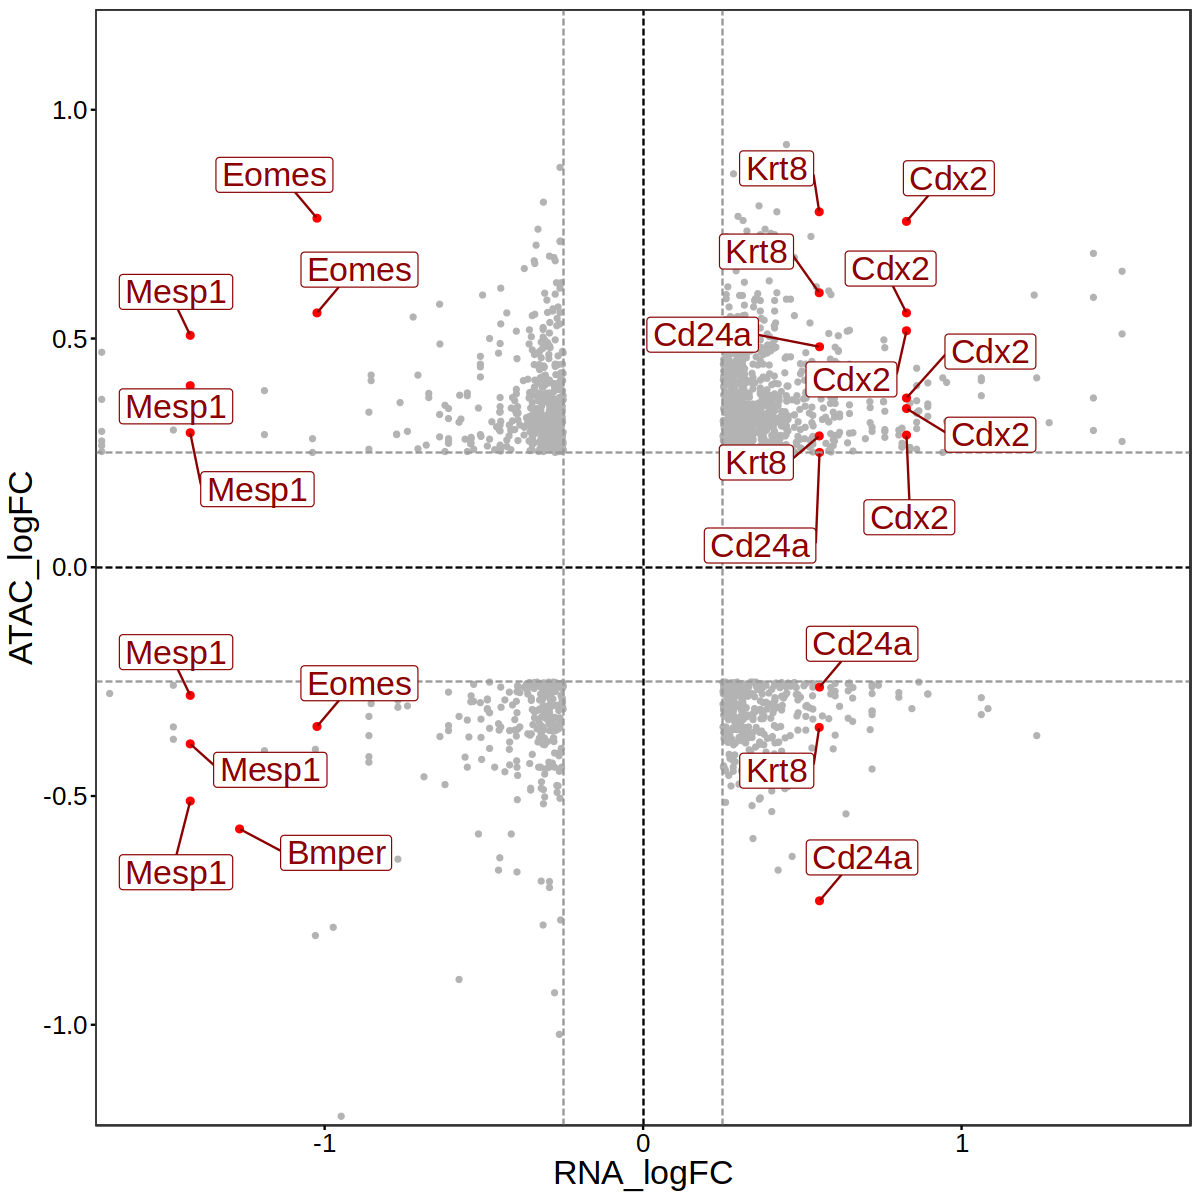

In [125]:
options(repr.plot.height= 10, repr.plot.width=10)
DEG_DAR = DEG_DAR[, ':='(RNA_logFC = ifelse(RNA_logFC < -1.7, -1.7, RNA_logFC),
                        ATAC_logFC = ifelse(ATAC_logFC < -1.2, -1.2, 
                                            ifelse(ATAC_logFC > 1.2, 1.2, ATAC_logFC)))]
                         
p1 = ggplot(DEG_DAR[celltype %in% c('Primitive_Streak')], aes(RNA_logFC, ATAC_logFC)) + 
    geom_point(size = 1, color = 'grey70') + 
    geom_point(data = DEG_DAR[celltype %in% c('Primitive_Streak')] %>%
                           .[gene %in% c('Mesp1', 'Eomes', 'Krt8', 'Cdx2', 'Bmper', 'Cd24a')],
               color = 'red') + 
    geom_hline(yintercept = c(-0.25, 0.25), linetype = 'longdash', color = 'grey60') + 
    geom_hline(yintercept = 0, linetype = 'longdash') + 
    geom_vline(xintercept = c(-0.25, 0.25), linetype = 'longdash', color = 'grey60') + 
    geom_vline(xintercept = 0, linetype = 'longdash') + 
    ggrepel::geom_label_repel(data = DEG_DAR[celltype %in% c('Primitive_Streak')] %>%
                           .[gene %in% c('Mesp1', 'Eomes', 'Krt8', 'Cdx2', 'Bmper', 'Cd24a')],
                       aes(label = gene), size = 7, color = 'darkred', fill = 'white',
                              box.padding = 1,
                              max.overlaps = Inf) + 

    scale_x_continuous(expand = c(0,0), limits = c(-1.72, 1.72)) + 
    scale_y_continuous(expand = c(0,0), limits = c(-1.22, 1.22)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
         axis.ticks = element_line(color='black'),
         panel.grid = element_blank(),
         panel.background = element_rect(color = 'black'),
         axis.title = element_text(size = 20))
p1

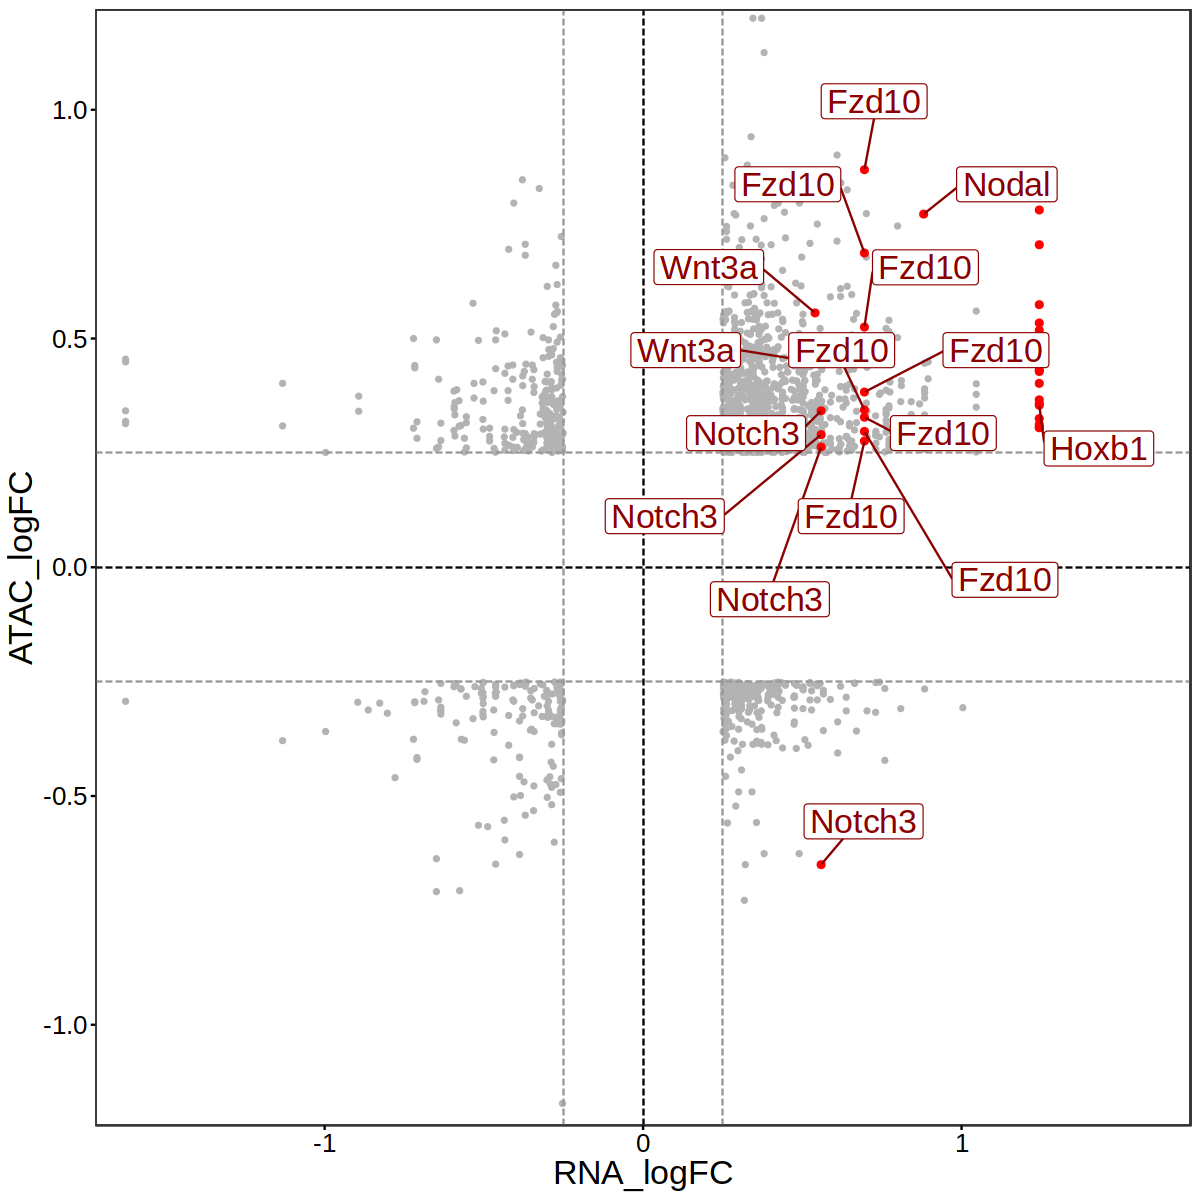

In [126]:
options(repr.plot.height= 10, repr.plot.width=10)
p2 = ggplot(DEG_DAR[celltype %in% c('Early_Mes_EOi')], aes(RNA_logFC, ATAC_logFC)) + 
    geom_point(size = 1, color = 'grey70') + 
    geom_point(data = DEG_DAR[celltype %in% c('Early_Mes_EOi')] %>%
                           .[gene %in% c('Notch3', 'Nodal', 'Fzd10', 'Wnt3a', 'Krt8', 'Hoxb1')],
               color = 'red') + 
    geom_hline(yintercept = c(-0.25, 0.25), linetype = 'longdash', color = 'grey60') + 
    geom_hline(yintercept = 0, linetype = 'longdash') + 
    geom_vline(xintercept = c(-0.25, 0.25), linetype = 'longdash', color = 'grey60') + 
    geom_vline(xintercept = 0, linetype = 'longdash') + 
    ggrepel::geom_label_repel(data = DEG_DAR[celltype %in% c('Early_Mes_EOi')] %>%
                           .[gene %in% c('Notch3', 'Nodal', 'Fzd10', 'Wnt3a', 'Krt8', 'Hoxb1')] %>%
                           .[!(gene == 'Hoxb1' & duplicated(gene))] ,
                       aes(label = gene), size = 7, color = 'darkred', fill = 'white',
                              box.padding = 1,
                              max.overlaps = Inf) + 

    scale_x_continuous(expand = c(0,0), limits = c(-1.72, 1.72)) + 
    scale_y_continuous(expand = c(0,0), limits = c(-1.22, 1.22)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 15, color = 'black'),
         axis.ticks = element_line(color='black'),
         panel.grid = element_blank(),
         panel.background = element_rect(color = 'black'),
         axis.title = element_text(size = 20))
p2

In [127]:
ggsave(file.path(args$outdir, 'multiome_KD_Early_RNAATACcomparison.pdf'), 
       plot = ggarrange(p1, p2, align = 'hv'),
       width = 400, 
       height = 200, 
       units = "mm")

In [10]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [12]:
WT_plot

celltype,genotype,path,name,color
<chr>,<chr>,<chr>,<fct>,<chr>
Primitive_Streak,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Primitive_Streak.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Primitive Streak WT,#000000
Primitive_Streak,KO,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Primitive_Streak.KO-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Primitive Streak KD,#FF0000
Early_Mes_EOi,WT,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Early_Mes_EOi.WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Early-Mes #1 WT,#000000
Early_Mes_EOi,KO,/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/GroupBigWigs/celltypeV2_genotype/Early_Mes_EOi.KO-TileSize-100-normMethod-ReadsInTSS-ArchR.bw,Early-Mes #1 KD,#FF0000


In [219]:
rna.sce$genotype = gsub('KO', 'KD', rna.sce$genotype)

In [14]:
rna.sce$celltype = rna.sce$celltype_v2

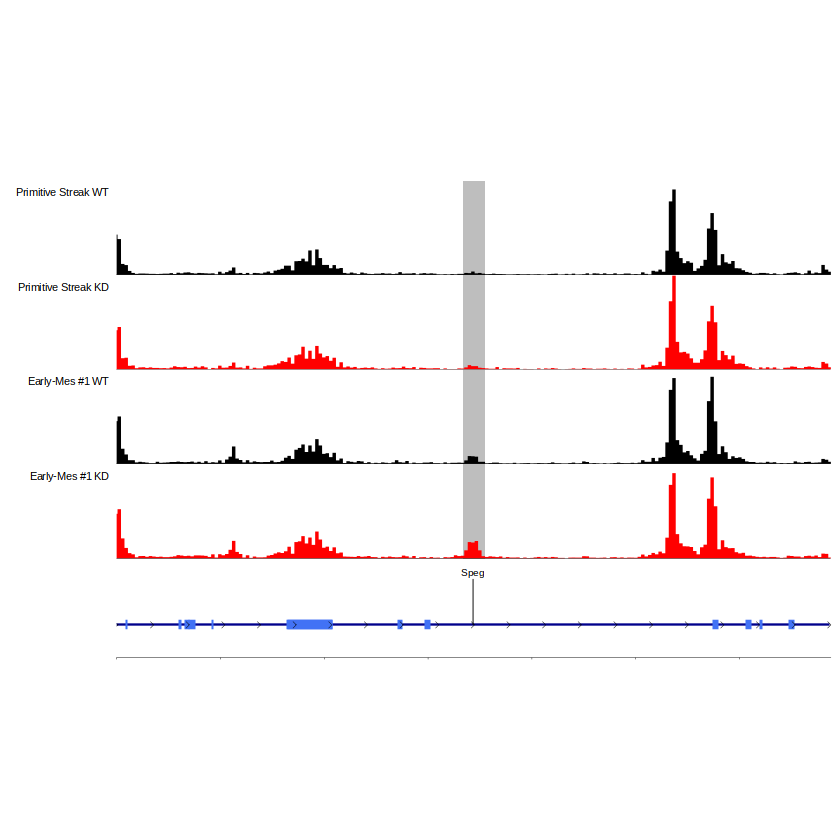

In [35]:
    plot_browser_track(gene = NULL, # gene used for plotting expression
                                  input_region = 'chr1:75392875-75393475', # Region used
                                  bigwigs = WT_plot, 
                                  extend.upstream = 1e4,
                                  extend.downstream = 1e4, 
                                  highlight_regions = unique(DARs$peak),
                                  downsample.rate = 1, 
                                  no_label = F, 
                                  plot_expression = F,
                                  background_color = 'white',
                                  highlight_color = 'grey',
                                  bw_height = 20, 
                                  gene_height = 20,
                                  bw_width = 100)

In [64]:
# Load differential RNA
DEGs = fread(sprintf('%s/DEGs_edgeR_pb.txt.gz', args$expression))[celltype %in% args$celltypes] %>% 
        .[,sig:=ifelse(abs(logFC)>0 & padj_fdr < 0.05, TRUE, FALSE)] %>% 
        .[sig == T] %>% .[, sig := NULL]
DEGs = DEGs[!gene %in% c('Hba-x', 'Hba-a1', 'Hba-a2', 'Hbb-bh1')]

# Load differential ATAC
DARs = fread(sprintf('%s/DARs_edgeR_pb.txt.gz', args$accessibility))[celltype %in% args$celltypes] %>% 
        .[,sig:=ifelse(abs(logFC)>0 & padj_fdr < 0.05, TRUE, FALSE)] %>% 
        .[sig == T] %>% .[, sig := NULL]

# Load peak2gene linkage
peak_gene_correlation = fread(file.path(args$WT_trajectory, 'acc_gene_correlation.txt.gz')) %>% 
    # .[padj<0.05] %>% 
    .[]

In [65]:
# link DEGs & DARs
DEG_DAR = DEGs %>% copy() %>%  
                    .[!is.na(logFC)] %>% 
                   setnames(colnames(.)[2:7], paste0('RNA_', colnames(.)[2:7])) %>% 
          merge(., peak_gene_correlation[,c('peak', 'gene', 'cor', 'padj')], 
                by = 'gene', allow.cartesian=TRUE) %>% 
          merge(., DARs %>% copy() %>%  
                    .[!is.na(logFC)] %>% 
                   setnames(colnames(.)[2:7], paste0('ATAC_', colnames(.)[2:7])),
                by = c('celltype', 'peak'), allow.cartesian=TRUE)

Warning message:
“ggrepel: 18 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


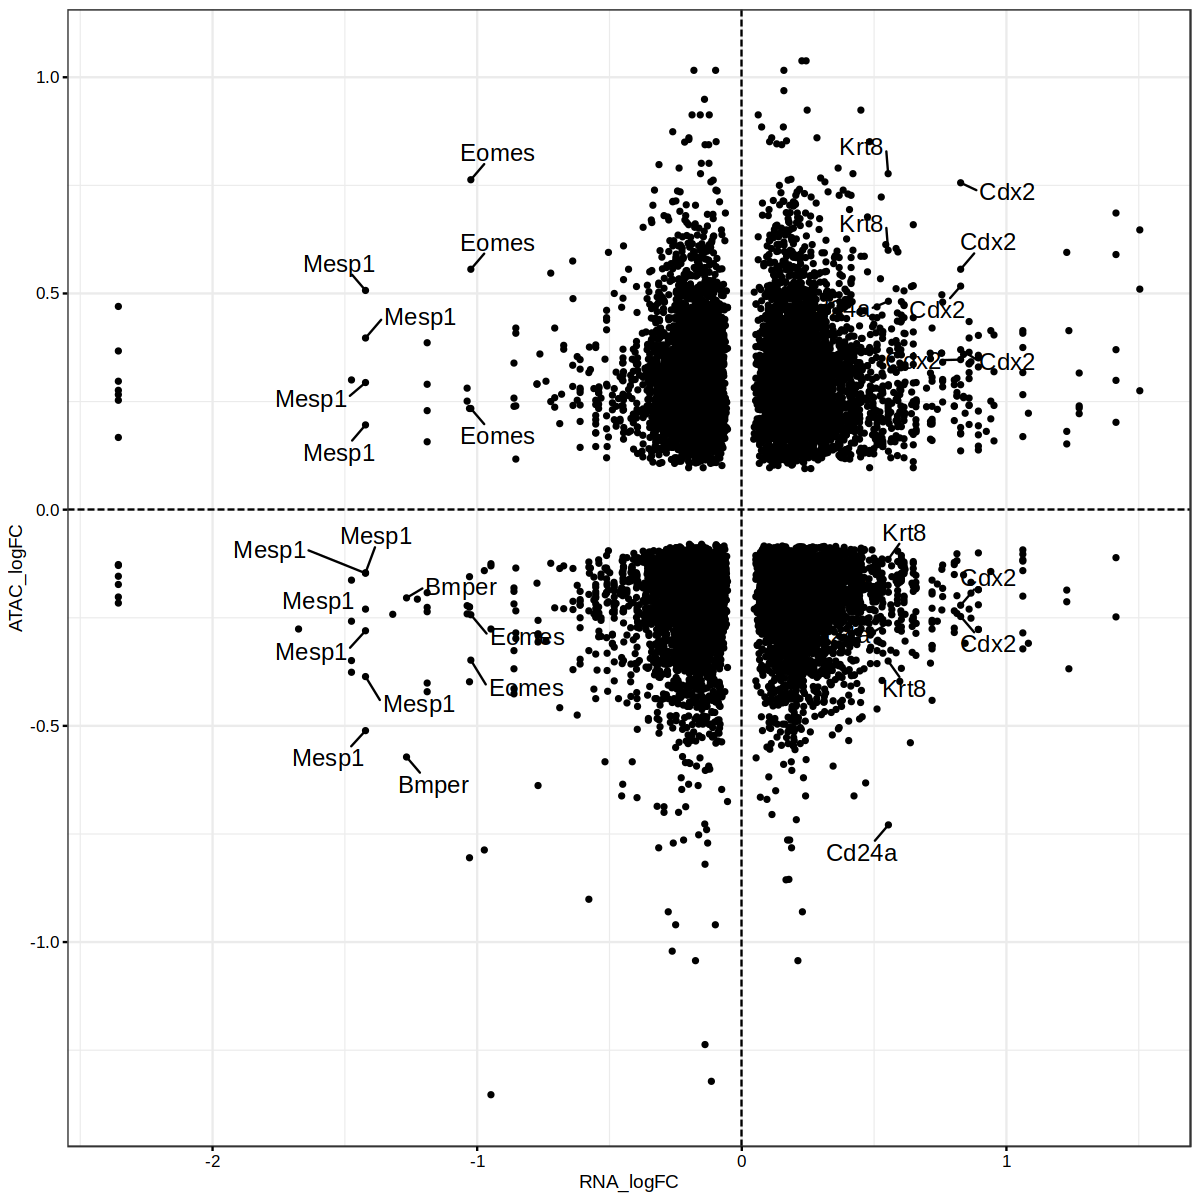

In [66]:
options(repr.plot.height= 10, repr.plot.width=10)
p1 = ggplot(DEG_DAR[celltype %in% c('Primitive_Streak')], aes(RNA_logFC, ATAC_logFC)) + 
    geom_point(size = 1) + 
    ggrepel::geom_text_repel(data = DEG_DAR[celltype %in% c('Primitive_Streak')] %>%
                           .[gene %in% c('Mesp1', 'Eomes', 'Krt8', 'Cdx2', 'Bmper', 'Cd24a')],
                       aes(label = gene), size = 5, box.padding = 0.7) + 
    geom_hline(yintercept = 0, linetype = 'longdash') + 
    geom_vline(xintercept = 0, linetype = 'longdash') + 
    theme_bw() + 
    theme(axis.text = element_text(size = 10, color = 'black'),
         axis.ticks = element_line(color='black'))
p1

Warning message:
“ggrepel: 87 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


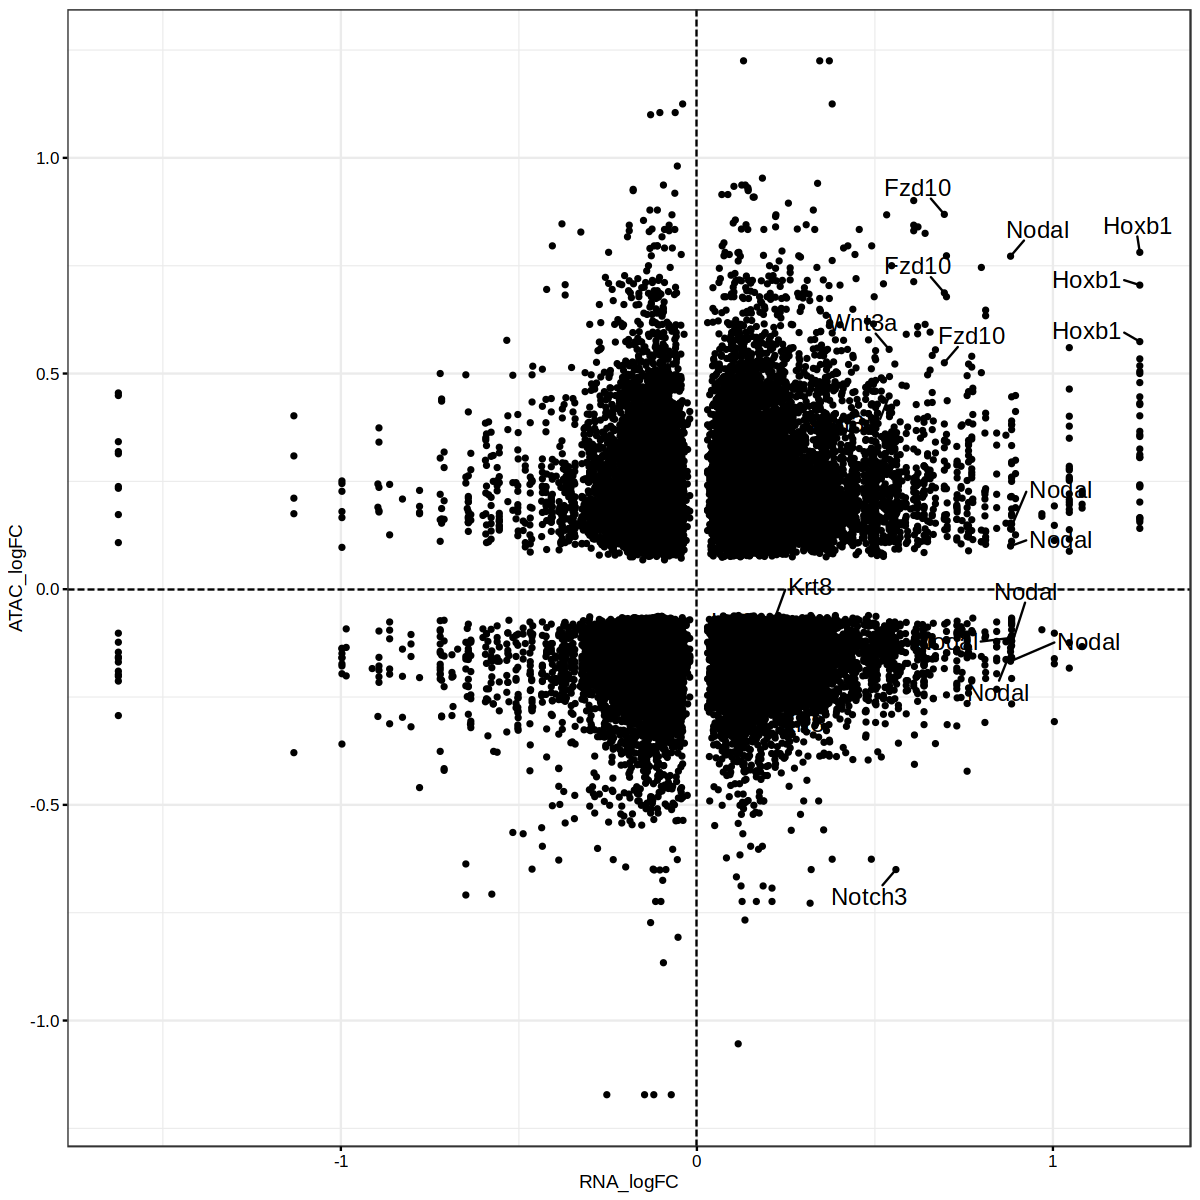

In [67]:
ggplot(DEG_DAR[celltype %in% c('Early_Mes_EOi')], aes(RNA_logFC, ATAC_logFC)) + 
    geom_point(size = 1) + 
    ggrepel::geom_text_repel(data = DEG_DAR[celltype %in% c('Early_Mes_EOi')] %>%
                           .[gene %in% c('Notch3', 'Nodal', 'Fzd10', 'Wnt3a', 'Krt8', 'Hoxb1')],
                       aes(label = gene), size = 5, box.padding = 0.7) + 
    geom_hline(yintercept = 0, linetype = 'longdash') + 
    geom_vline(xintercept = 0, linetype = 'longdash') + 
    theme_bw() + 
    theme(axis.text = element_text(size = 10, color = 'black'),
         axis.ticks = element_line(color='black'))